# Lesson 1A 

In this class we will learn how to work with networks in R:

- Creating networks: manually and from files
- Saving networks: formats 
- Basic metrics: nodes, links, degree/connectivity
- Structure

## Introduction to graphs in R

In this course we will work with networks using a small set of key R libraries. 

We will use **igraph** as the main tool to create and analyse networks, since it allows us to work with graphs, compute network metrics, and apply different algorithms. 

Data manipulation will be done using the **tidyverse**, which makes it easier to handle tables associated with networks. 

For visualisation, we will use **ggraph**, which allows flexible and clear network representations.
 
In addition, for ecological networks such as plant–pollinator systems, we will also use specialised packages like **bipartite**, designed specifically for the analysis of these types of networks.


## Importing the required libraries


In [1]:
# If needed (run once):
# install.packages(c("igraph","tidyverse","tidygraph","ggraph"))

library(igraph)
library(tidyverse)
library(tidygraph)
library(ggraph)



Attaching package: ‘igraph’


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ lubridate::%--%()      masks igraph::%--%()
✖ dplyr::as_data_frame() masks tibble::as_data_frame(), igraph::as_data_frame()
✖ purrr::compose()       masks igraph::compose()
✖ tidyr::crossing()      masks igraph::crossing()
✖ dplyr::filter()        masks stats::filter()
✖ dplyr::lag()           masks stats::lag()
✖ purrr::simplify()      masks igraph::simplify()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


ERROR: Error in library(tidygraph): there is no package called ‘tidygraph’


In [2]:
source("Functions.R") #include some helpers

## Creating and drawing simple graphs
**igraph** offers many ways to create a graph. The simplest one is the function `make_empty_graph()`:

In [3]:
g <- make_empty_graph()

To add one or more vertices to an existing graph, use `add_vertices()`

In [5]:
g <- add_vertices(g, 37) 

#Note: If you try to add edges to vertices with invalid IDs (i.e., you try to add an edge to vertex 38 when the graph has only 37 vertices), 
#igraph shows an error:

Similarly, to add edges you can use `add_edges()`. Edges are added by specifying the source and target vertex IDs for each edge. This call added three edges, one connecting vertices 1 and 35, one connecting vertices 1 and 36, and one connecting vertices 34 and 37.

In [6]:
g <- add_edges(g, edges = c(1,35, 1,36, 34,37))

The most common way to create a graph is make_graph(), which constructs a network based on specified edges. For example, to make an undirected graph with 5 nodes (numbered 1 to 5) and 4 edges:

In [7]:
# from list of edges (it assumes n=maximum value of elements in )
EdgeList1 <- c(1,2, 1,3, 2,3, 3,5)
g1 <- graph(edges=EdgeList1, directed=FALSE)
g1$name <- "Example network"

We can print the graph to get a summary of its nodes and edges:

In [8]:
g1

IGRAPH ae347fe U--- 5 4 -- Example network
+ attr: name (g/c)
+ edges from ae347fe:
[1] 1--2 1--3 2--3 3--5

This means: Undirected graph with 5 vertices and 4 edges, with the exact edges listed out. If the graph has a [name] attribute, it is printed as well.

We can retrieve the nodes(vertices) as `V(g)` and the links(edges) as `E(g)`, to iterate trouhg them.

In [54]:
print(V(g1))
print(E(g1))

+ 5/5 vertices, from ae347fe:
[1] 1 2 3 4 5
+ 4/4 edges from ae347fe:
[1] 1--2 1--3 2--3 3--5


And the general information with summary

In [55]:
print(class(g1))
summary(g1)

[1] "igraph"
IGRAPH ae347fe U--- 5 4 -- Example network
+ attr: name (g/c)


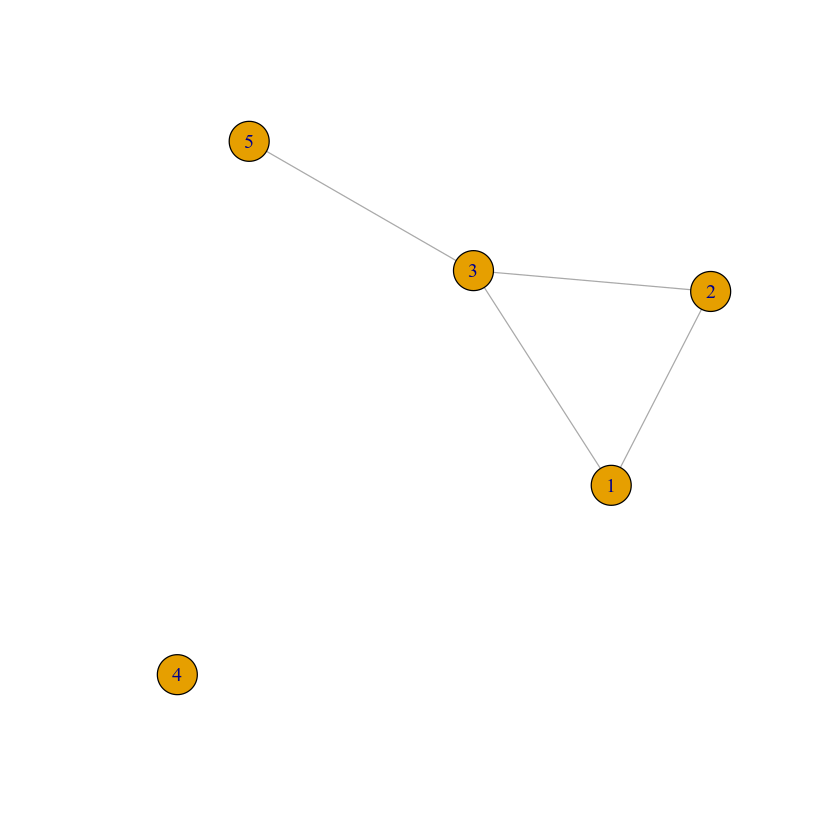

In [10]:
plot(g1)

There are many optional arguments to the draw function to customize the appearance.

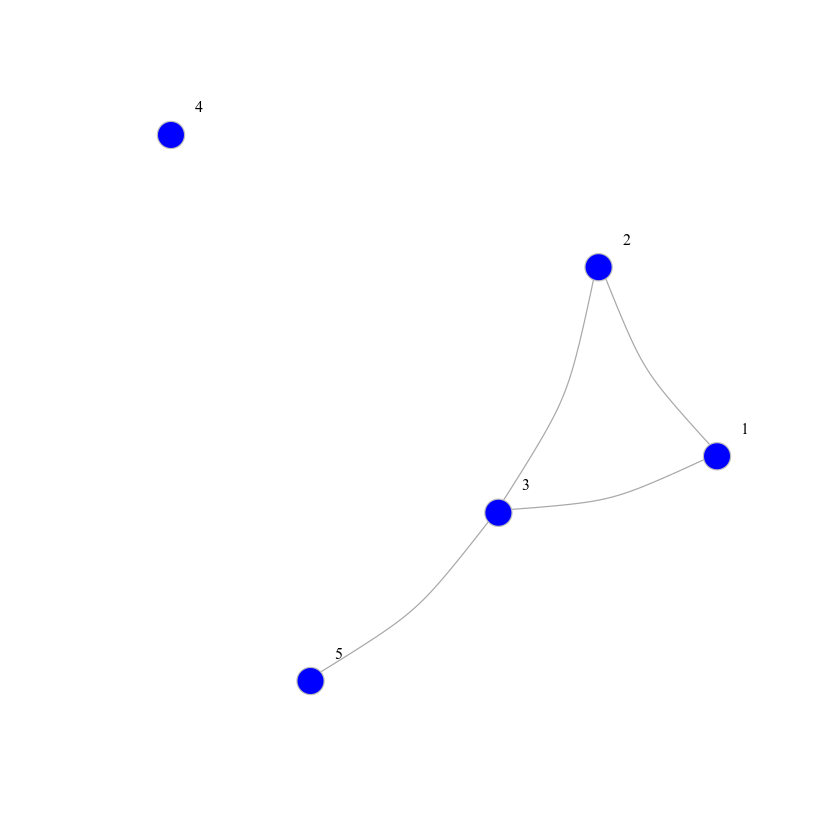

In [11]:
plot(g1, vertex.color="blue", vertex.size=10, 

     vertex.frame.color="gray", vertex.label.color="black", 

     vertex.label.cex=0.8, vertex.label.dist=2, edge.curved=0.2) 


<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>

<h3> Exercise 1</h3>
Create the undirected graph corresponding to this simple network

![title](./images/figure1.png)
</div>

In [12]:
# write your code here and run it ################
#g2<-

```r
 EdgeList1 <- c(1,2, 2,3, 3,4, 3,5)
g2 <- graph(edges=EdgeList1, directed=FALSE)
plot(g2,vertex.color="white",vertex.frame.color="black", vertex.label.color="black",edge.color="black",vertex.size=20) 
```

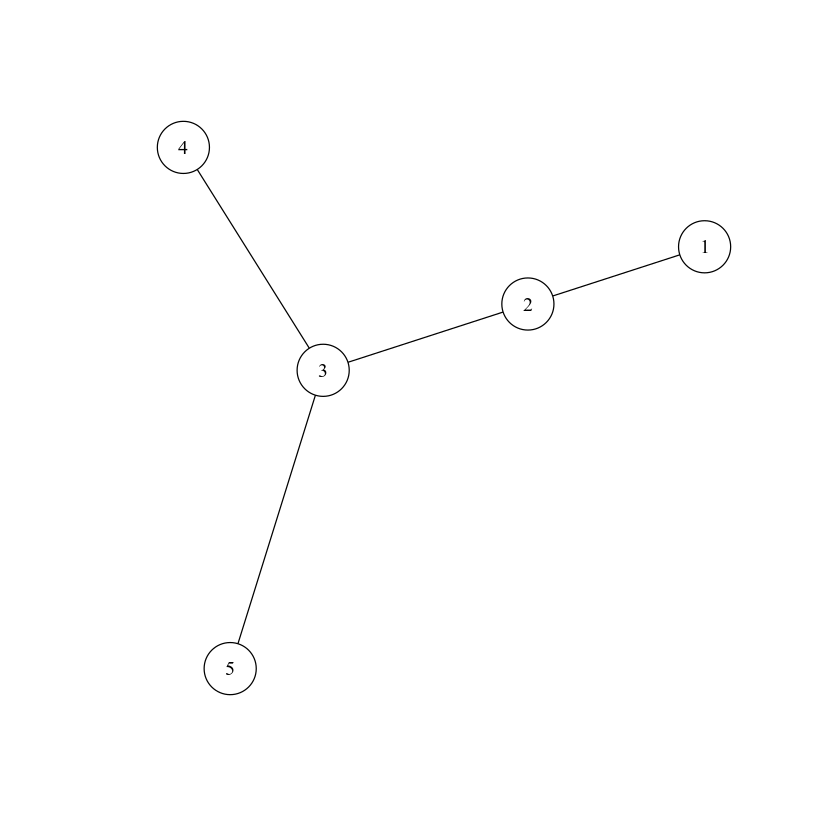

In [ ]:
# SOLUTION: uncomment line below to load solution
load_and_show("./snippets/ex1.R")


We now have an undirected graph with 5 vertices and 4 edges. 
Vertex and edge IDs are always contiguous, so if you delete a vertex all subsequent vertices will be renumbered. 
When a vertex is renumbered, edges are not renumbered, but their source and target vertices will be.
Use `delete_vertices()` and `delete_edges()` to perform these operations.

In [14]:
g2

IGRAPH bd62bd2 U--- 5 4 -- 
+ edges from bd62bd2:
[1] 1--2 2--3 3--4 3--5

In [17]:
edge_id_to_delete <- get.edge.ids(g2, c(2, 3))
edge_id_to_delete

[1] 2

In [19]:
g2 <- delete_edges(g2, edge_id_to_delete)
g2

IGRAPH 000f7c1 U--- 5 3 -- 
+ edges from 000f7c1:
[1] 1--2 3--4 3--5

## Creating non-simple Graphs - Edge properties
As we have seen, we can add different attributes to edges and nodes to enrich the information contained in the network. 
Usually much information can be incuding regarding the "interaction" between a couple of nodes. 
The most frequent examples are direction and weigth.

### Directed graphs
Unless otherwise specified, we assume graph edges are undirected -- they are symmetric and go both ways. 
But some relationships, e.g. predator-prey relationships, are asymmetric and best represented as directed graphs. 
In igraph we can make a directed graph by indicating in the construction that edges are NOT simmetric. 
Let's create a **Directed graph**

In [20]:
edges <- c(
  1, 2,
  1, 3,
  2, 3,
  2, 4,
  3, 4,
  3, 5,
  4, 5,
  4, 6,
  5, 6,
  6, 3
)

# Create the directed graph
dg <- graph(edges = edges, directed = TRUE)


<div style="background-color:#d4edda; border-left:6px solid #28a745; padding:12px; border-radius:4px; color:#000;"><b> Up to you:</b>
<h3> Exercise 2</h3>
Create the directed graph corresponding to this simple network

![title](./images/figure2.jpg)
</div>

In [21]:
# write your code here and run it ################
#g3<-

```r
 g3 <- graph(
  edges = c(
    "plant", "snail",
    "plant", "caterpillar",
    "plant", "rabbit",
    "snail", "lizard",
    "caterpillar", "lizard"
  ),
  directed = TRUE
)
plot(g3,vertex.color="white",vertex.frame.color="black", vertex.label.color="black",edge.color="black",vertex.size=20) 
```

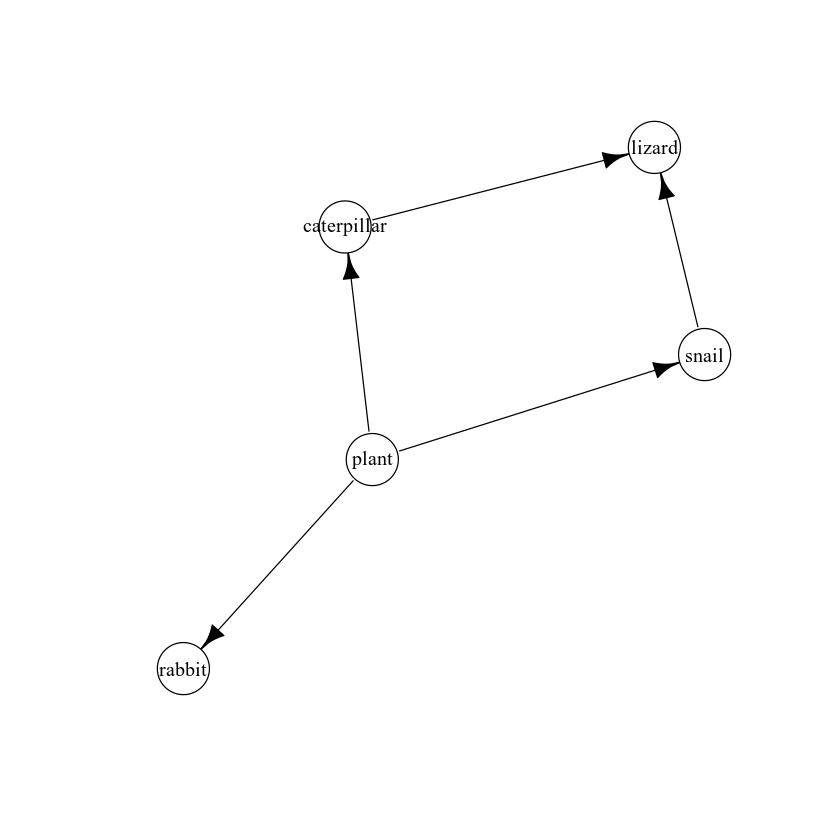

In [57]:
# SOLUTION: uncomment line below to load solution
load_and_show("./snippets/ex2.R")
#source("./snippets/ex1.R")

### Weighted graphs
We can add further information to the edges between nodes. Including the weigth of the interaction is very frequent. We can create a weighted network by adding the `ẁeigth` attribute to the edges in the network 


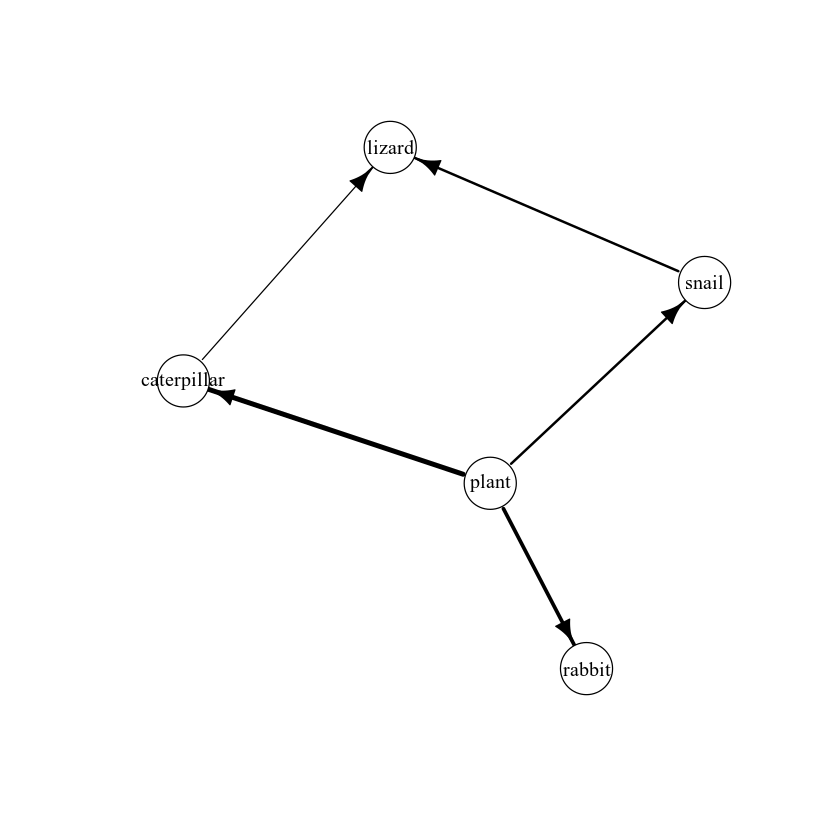

In [65]:
E(g3)$weight <- c(2, 4, 3, 2, 1)
plot(g3,vertex.color="white",vertex.frame.color="black", vertex.label.color="black",edge.color="black",edge.width = E(g3)$weight,vertex.size=20) 

## Creating non-simple Graphs - Node properties
In some cases we have different clases of nodes, for example plants and pollinators, or seed and dispersers. In this case the interactions only take place between nodes of different sets. These types of networks are called **bipartite nnetworks** (because we have two different types of nodes), or multipartite networks if we have more than two different sets. Now, the attribute belongs to the **node**, not to the link. 

### Bipartite graphs
This type of networks are very frequent in ecology. While *igraph* does not have a dedicated bipartite graph class, the normal graph classes can be used to represent bipartite graphs. However, you have to keep track of which set each node belongs to, and make sure that there is no edge between nodes of the same set. The convention used in *igraph* is to use a node attribute named `type` with values TRUE or FALSE to identify the sets each node belongs to. This convention is not enforced in the code of *igraph* functions, it’s only a recommendation. Let's see how we can create a bipartite network using *igraph*.

In [46]:
B <- make_empty_graph(directed=FALSE) + vertices(c("P1","P2","A1","A2","A3")) #two plants and three animals
V(B)$type <- c(TRUE, TRUE, FALSE, FALSE, FALSE) #plants have type TRUE (bottom set) and animals type TRUE (upper set). We NEED to specify it
B <- add.edges(B,c("P1","A1",   "P2","A2",   "P2","A3"))
is_bipartite(B)

[1] TRUE

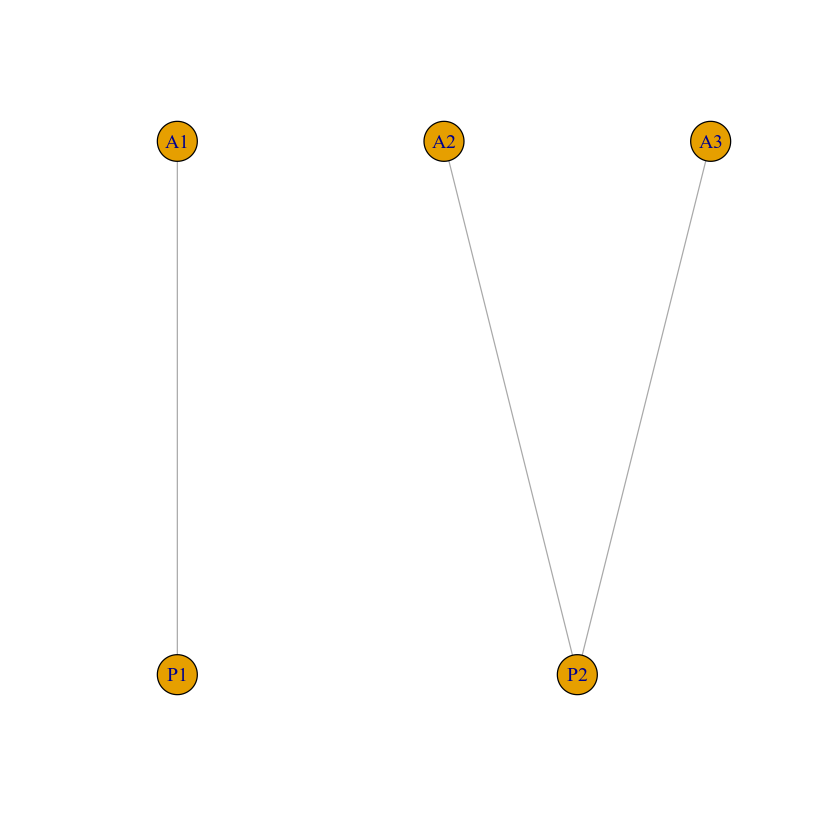

In [47]:
plot(B, layout = layout_as_bipartite)

#### Obtaining the bipartite sets
If B is connected, you can find the two node sets using a two-coloring algorithm. However, if the input graph is not connected, there are more than one possible colorations, and raise an `AmbiguousSolution Exception` if the input graph for bipartite.sets is disconnected. In these cases, Using the bipartite node attribute, you can easily get the two node sets

In [66]:
top_nodes <- V(B)$name[V(B)$type == FALSE] #animals
bottom_nodes <- V(B)$name[V(B)$type == TRUE] #plants

In [68]:
top_nodes

[1] "A1" "A2" "A3"

#### One mode projection of bipartite networks

### Exercise 8
1. Project the bipartite network into plant-plant and pollinator-pollinator networks.
2. Compute degree distributions of each projection.


In [ ]:
proj <- bipartite_projection(gB)
g_plants <- proj$proj1
g_polls  <- proj$proj2

degree(g_plants) |> summary()
degree(g_polls)  |> summary()


# Working with network files & formats

This section mirrors reading/writing graphs and converting between graphs and data frames.


### Save to file

### Exercise 9
1. Save a graph to GraphML.
2. Read it back.


In [ ]:
# Choose a path you can write to
out_graphml <- "lesson01_example.graphml"

write_graph(g, out_graphml, format = "graphml")
g2 <- read_graph(out_graphml, format = "graphml")

g2


### Networks as Dataframes

### Exercise 10
1. Convert edges and nodes to data frames.
2. Rebuild the graph from those tables.


In [ ]:
edges_df <- as_data_frame(g, what = "edges") |> as_tibble()
nodes_df <- as_data_frame(g, what = "vertices") |> as_tibble()

edges_df
nodes_df

g_rebuilt <- graph_from_data_frame(edges_df, directed = FALSE, vertices = nodes_df)
isomorphic(g, g_rebuilt)


### Reading from files

We'll cover two common cases:
- Reading a matrix (adjacency or incidence)
- Reading an interaction list (edge list)


#### Reading a Matrix

### Exercise 11
1. Create an adjacency matrix.
2. Build a graph from it.


In [ ]:
A <- matrix(c(
  0,1,1,0,
  1,0,1,0,
  1,1,0,1,
  0,0,1,0
), nrow = 4, byrow = TRUE)

rownames(A) <- colnames(A) <- paste0("N", 1:4)

gA <- graph_from_adjacency_matrix(A, mode = "undirected", diag = FALSE)
gA


#### Reading an interaction list

### Exercise 12
1. Save an edge list CSV.
2. Read it and build a graph.


In [ ]:
# Create and save an edge list
edge_list_path <- "edge_list.csv"
write_csv(edges, edge_list_path)

# Read it
edges_in <- read_csv(edge_list_path, show_col_types = FALSE)
g_from_file <- graph_from_data_frame(edges_in, directed = FALSE)

g_from_file


## Next steps (we'll do after)

Your original `Lesson01_A` calls helper functions from `Functions.py`. Once you're ready, we can:

- Port the **exact helpers** to R (or rewrite them idiomatically)
- Replace the toy networks here with the **same datasets** used in the course
- Match every exercise cell-by-cell against the Python notebook
